# Building Makemore from scratch

In [146]:
words = open('names.txt', 'r').read().splitlines()

In [147]:
import torch

In [148]:
N = torch.zeros((27, 27), dtype=torch.int32)

In [149]:
chars = sorted(list(set(''.join(words))))

stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for i, s in stoi.items()}

In [ ]:
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1

tensor([    0, 22050,  6530,  7710,  8450,  7655,  2085,  3345,  4370,  2955,
        12110, 14815,  7860, 12690,  5730,  1970,  2575,   460,  8195, 10275,
         6540,   390,  1880,  1535,   670,  2675,  4645], dtype=torch.int32)

KeyError: 0

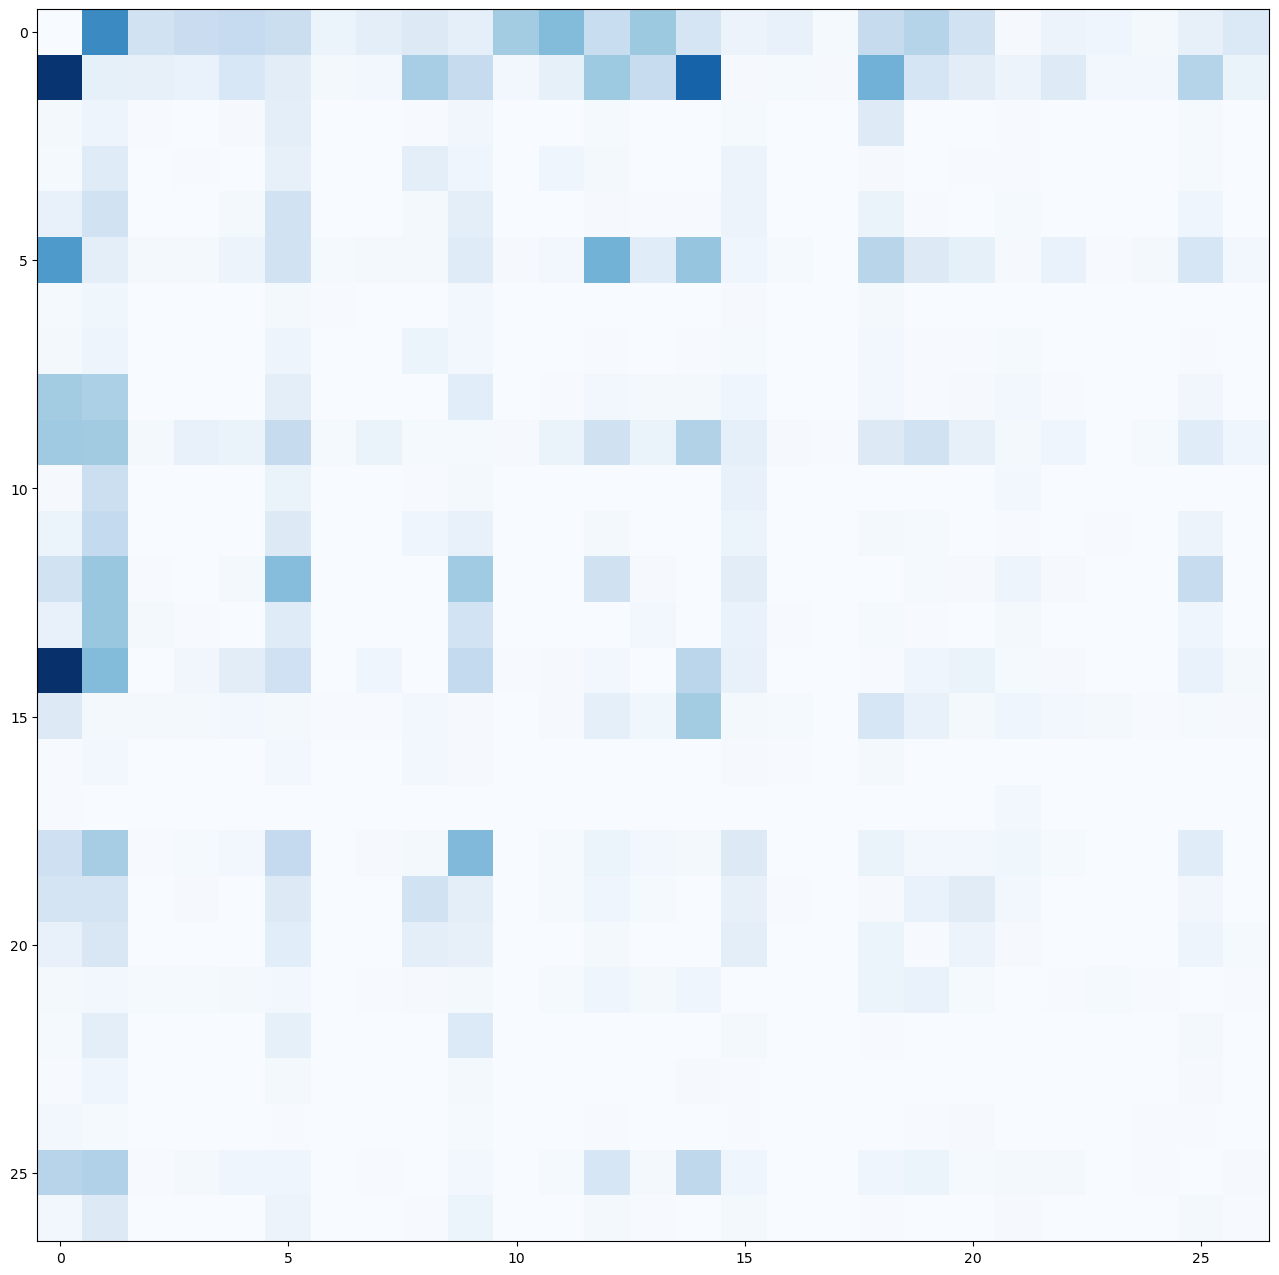

In [143]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off');

### Now, we're going to normalize the rows.

But, why?
Because our random character sampler samples based on probability distributions. So, since our generator looks at characters row-wise, we want to normalize each row to a perfect probability distribution.

### Wait, why don't we just pick the bi-gram with the highest probability?

Where's the fun in that? How else are we supposed to generate unique, interesting, and even gross names?

### So, how do we even normalize the rows?

simple, just get the sum of the each row, and divide every single element in the row with that sum. In the end, the sum of all of the supposed probability distributions must be equal to 1.

In [111]:
# First up, we have to figure out a way to get the sum: torch.sum()
# Then, we have to divide all of the values in each tensor, in the list of tensors N.
# This is where the principles of broadcasting are going to be useful. See notebook: broadcasting_practice.ipynb

P = torch.zeros(27, 27)

for i in range(len(N)):
    div = N[i].sum()
    for j in range(27):
        P[i, j] = N[i, j] / div

# So, now P is the resulting matrix, where all the rows are probability distributions summing up to 1.

In [112]:
# Now, that we have the rows as prob distributions, we want a generator, and a way to sample probabilities.

g = torch.Generator().manual_seed(2147483647)

In [ ]:
# Now, let's play around with the multinomial method a bit.

w = torch.tensor([0.04, 0.6, 0.05, 0.01, 0.21, 0.09])

res = torch.multinomial(w, 10000, replacement=True, generator=g)

In [ ]:
# ok, now, the input weight tensor will be the row of the current character in P.
# so, we first start from ".", i.e. row 0